Gráfico de Linhas

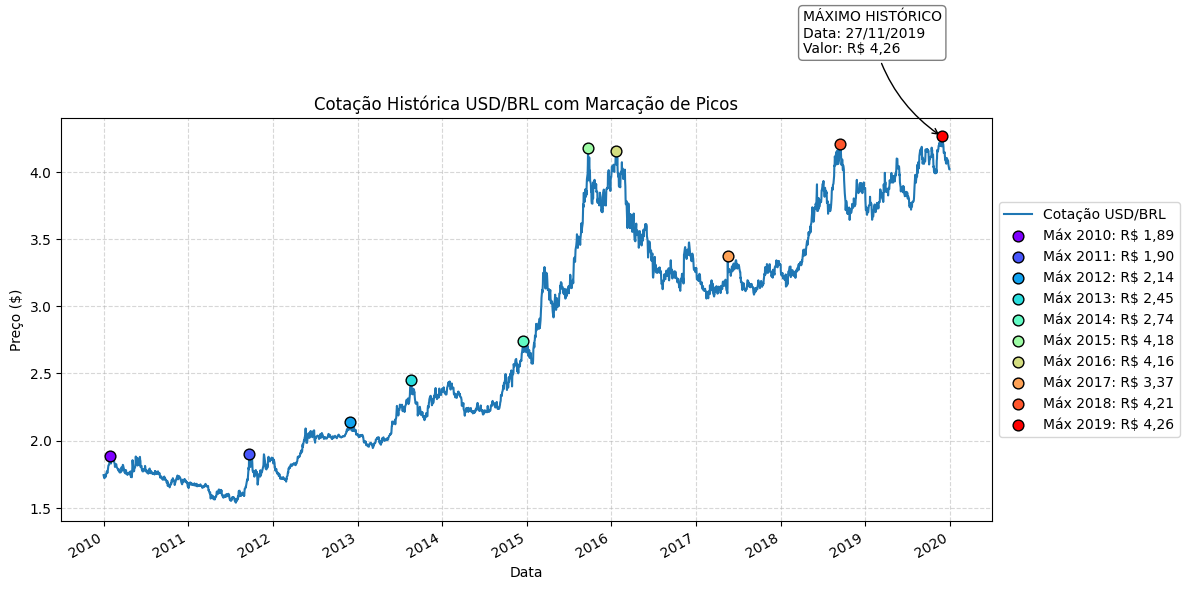

In [ ]:
from pandas import read_csv
from matplotlib import pyplot
import matplotlib.cm as cm
import numpy as np

# --- 1. A BASE: Carregamento e Preparação ---
series = read_csv("USD_BRL_hist.csv", header=0, index_col=0, parse_dates=True, dayfirst=True)
dolar = series.iloc[:, 0]

# Identificação dos Extremos
datas_max_anuais = dolar.groupby(dolar.index.year).idxmax()
valores_max_anuais = dolar.loc[datas_max_anuais]

data_max_absoluto = dolar.idxmax()
valor_max_absoluto = dolar.loc[data_max_absoluto]

# --- 2. O MEIO: Renderização Base ---
pyplot.figure(figsize=(12, 6))
dolar.plot(label="Cotação USD/BRL")

# --- 3. O TOPO: Camada Visual e Anotações ---

# a) Rótulos com Valores: Construindo a legenda no padrão "Max Ano: R$0,00"
cores = cm.rainbow(np.linspace(0, 1, len(valores_max_anuais)))

for (data, valor), cor in zip(valores_max_anuais.items(), cores):
    # Formata para 2 casas decimais e substitui ponto por vírgula
    valor_formatado = f"{valor:.2f}".replace('.', ',')
    label_texto = f'Máx {data.year}: R$ {valor_formatado}'

    pyplot.scatter(data, valor, color=cor, zorder=5, s=60, edgecolors='black', label=label_texto)

# b) A estrela amarela foi suprimida desta camada (código de scatter removido)

# c) Posicionamento da Anotação: Movendo a caixa para cima do ponto
valor_max_formatado = f"{valor_max_absoluto:.2f}".replace('.', ',')
texto_anotacao = f'MÁXIMO HISTÓRICO\nData: {data_max_absoluto.strftime("%d/%m/%Y")}\nValor: R$ {valor_max_formatado}'

pyplot.annotate(texto_anotacao,
             xy=(data_max_absoluto, valor_max_absoluto),
             xytext=(-100, 60), # <- ALTERAÇÃO AQUI: Y positivo (60) move a caixa para cima
             textcoords='offset points',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color='black'))

# Finalização da renderização
pyplot.title("Cotação Histórica USD/BRL com Marcação de Picos")
pyplot.ylabel("Preço ($)")
pyplot.xlabel("Data")
pyplot.grid(True, linestyle='--', alpha=0.5)

# Legenda posicionada fora da área do gráfico
pyplot.legend(loc='center left', bbox_to_anchor=(1, 0.5))
pyplot.tight_layout()

pyplot.show()

Gráfico de Dispersão (Scatter Plot)

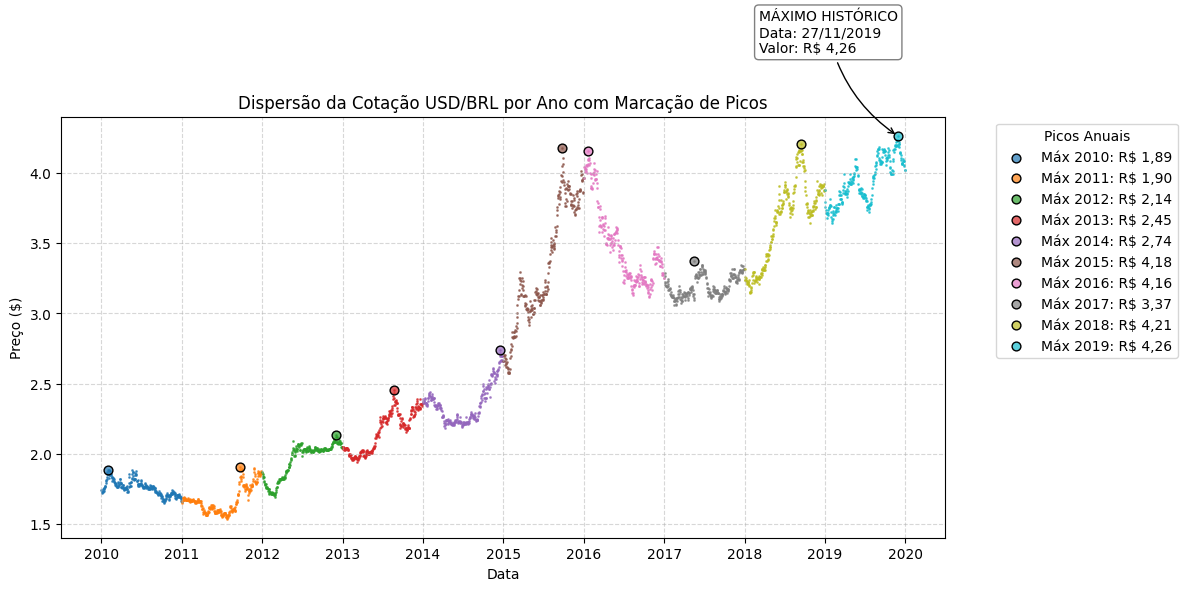

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. A BASE: Extração e Preparação ---
df = pd.read_csv("USD_BRL_hist.csv", header=0, index_col=0, parse_dates=True, dayfirst=True)
dolar = df.iloc[:, 0]

data_max_absoluto = dolar.idxmax()
valor_max_absoluto = dolar.loc[data_max_absoluto]

# --- 2. O MEIO: Inicialização do Quadro ---
plt.figure(figsize=(12, 6))

# --- 3. O TOPO: Renderização das Camadas ---
for year, data in dolar.groupby(dolar.index.year):

    data_max_ano = data.idxmax()
    valor_max_ano = data.loc[data_max_ano]

    # ALTERAÇÃO ESTRUTURAL: Redução da área (size) dos pontos diários
    # Parâmetro 's' alterado de 3 para 1 para evitar a fusão visual da nuvem de dispersão
    scatter_base = plt.scatter(data.index, data, s=1, alpha=0.7)

    cor_do_ano = scatter_base.get_facecolors()[0]

    valor_formatado = f"{valor_max_ano:.2f}".replace('.', ',')
    label_texto = f'Máx {year}: R$ {valor_formatado}'

    # ALTERAÇÃO ESTRUTURAL: Redução proporcional dos marcadores de pico
    # Parâmetro 's' alterado de 60 para 40 para manter a harmonia visual
    plt.scatter(data_max_ano, valor_max_ano, color=cor_do_ano,
                zorder=5, s=40, edgecolors='black', label=label_texto)

# Anotação do Máximo Histórico
valor_max_abs_formatado = f"{valor_max_absoluto:.2f}".replace('.', ',')
texto_anotacao = f'MÁXIMO HISTÓRICO\nData: {data_max_absoluto.strftime("%d/%m/%Y")}\nValor: R$ {valor_max_abs_formatado}'

plt.annotate(texto_anotacao,
             xy=(data_max_absoluto, valor_max_absoluto),
             xytext=(-100, 60),
             textcoords='offset points',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color='black'),
             zorder=6)

# Configurações Finais de Layout
plt.title('Dispersão da Cotação USD/BRL por Ano com Marcação de Picos')
plt.ylabel('Preço ($)')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(title='Picos Anuais', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Gráfico de Barras

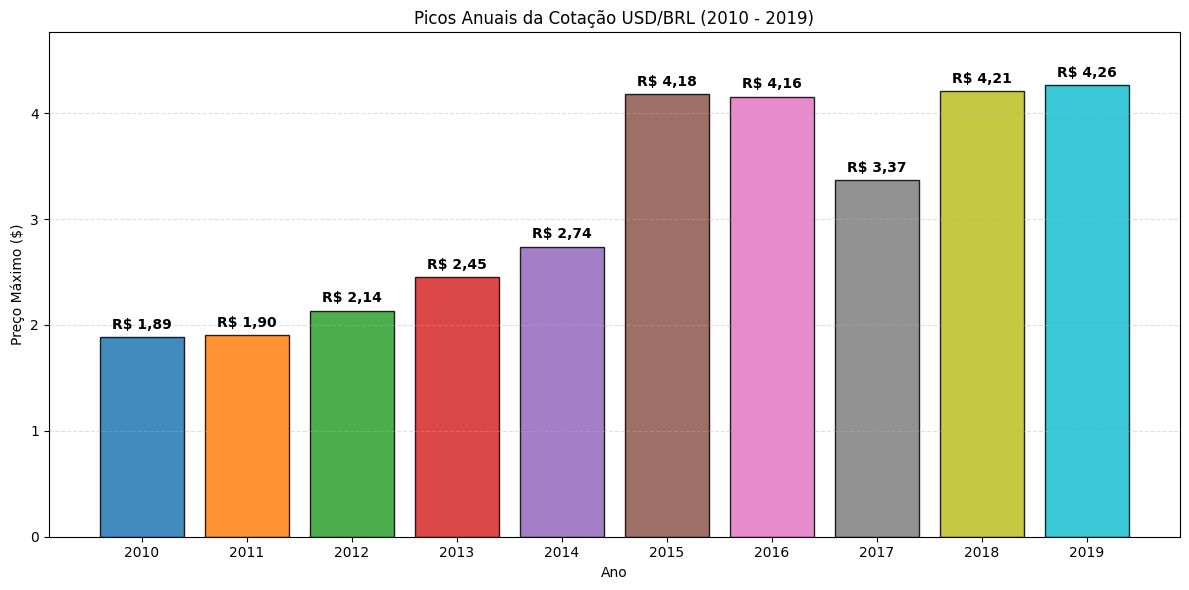

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- 1. A BASE: Extração e Lógica de Dados ---
# Leitura do CSV configurando a data como índice para facilitar operações temporais
df = pd.read_csv("USD_BRL_hist.csv", header=0, index_col=0, parse_dates=True, dayfirst=True)
dolar = df.iloc[:, 0]

# Agrupa todos os registros pelo ano e extrai o valor máximo de cada pacote anual
picos_anuais = dolar.groupby(dolar.index.year).max()

# Garante o recorte exato da década de 2010 a 2019
picos_anuais = picos_anuais.loc[2010:2019]

anos = picos_anuais.index
valores = picos_anuais.values

# --- 2. O MEIO: Renderização Base das Barras ---
plt.figure(figsize=(12, 6))

# Gera um gradiente com 10 cores distintas (uma para cada ano)
cores = cm.tab10(np.linspace(0, 1, len(anos)))

# Constrói o gráfico de barras
barras = plt.bar(anos, valores, color=cores, edgecolor='black', alpha=0.85)

# --- 3. O TOPO: Refinamento Visual e Anotações ---
# Percorre cada barra desenhada para fixar o valor exato no topo dela
for barra in barras:
    altura = barra.get_height()
    valor_formatado = f"R$ {altura:.2f}".replace('.', ',')

    # Adiciona o texto um pouco acima (altura + 0.05) do limite da barra
    plt.text(barra.get_x() + barra.get_width()/2., altura + 0.05,
             valor_formatado, ha='center', va='bottom', fontsize=10, fontweight='bold')

# Força o eixo X a exibir todos os números dos anos redondos (sem quebrar em decimais)
plt.xticks(anos)

# Dá uma margem extra no limite superior do eixo Y para os textos não cortarem
plt.ylim(0, max(valores) + 0.5)

# Configurações finais de texto e layout
plt.ylabel('Preço Máximo ($)')
plt.xlabel('Ano')
plt.title('Picos Anuais da Cotação USD/BRL (2010 - 2019)')

# Grade horizontal suave para guiar os olhos
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()